In [49]:
# --- snippet: imports
import yfinance as yf
import pandas as pd
import numpy as np
import numpy.typing as npt
from scipy.optimize import newton
import plotly.graph_objects as go
import itables

itables.init_notebook_mode()
itables.options.allow_html = True
# itables.options.searching = False
itables.options.warn_on_undocumented_option = False
# --- endsnippet

In [50]:
# --- snippet: helper_functions
# Rate Periodicity Conversion
def equivRate(rate: float, from_freq: int = 1, to_freq: int = 1) -> float:
    return to_freq * ((1 + rate / from_freq) ** (from_freq / to_freq) - 1)


# Present Value Function
def pv(r: float, n: int, pmt: float, fv: int = 0, beg: bool = False) -> float:
    c: npt.NDArray[np.float64] = np.full(n, pmt)  # array of payments
    t: npt.NDArray[np.int64] = np.arange(1, n + 1)  # array of periods
    d: npt.NDArray[np.float64] = 1.0 / np.power((1 + r), t)  # discount factors
    B: float = float(np.sum(d * c))  # present value of payments
    tv: float = fv / (1 + r) ** n  # discounted future value

    return float(np.where(beg, (B + tv) * (1 + r), B + tv))


# Amortizing Loan Principal Outstanding Balance
def principal_out(
    P: float, r: float, N: int, n: npt.NDArray[np.int64]
) -> npt.NDArray[np.float64]:
    d1: npt.NDArray[np.float64] = (1 + r) ** N - (1 + r) ** (n - 1)
    d2: float = (1 + r) ** N - 1
    return P * d1 / d2


# --- endsnippet

In [51]:
# --- snippet: inputs
fx_rate: float = 1 / 3.67  # AED/USD rate
currency: str = "AED"

start_date: pd.Timestamp = pd.to_datetime("2020-01-01")
end_date: pd.Timestamp = pd.DateOffset(months=12 * 12) + start_date
eval_end_date: pd.Timestamp = pd.to_datetime("2025-10-01")

# Real Estate Investment
property_val: int = 510_000
down_payment: float = property_val * 0.2
loan_amount: float = property_val - down_payment

emi: float = 3_500.0
n_period: int = 12 * 12

interest_rate: float = newton(
    lambda r: pv(r=r, n=n_period, pmt=emi, beg=False) - loan_amount, x0=0
)

annual_rent: float = 36_000.0
annual_rent_gwth: float = 0.05
annual_appreciation: float = 0.05
monthly_appreciation: float = equivRate(annual_appreciation, 1, 12) / 12

# Closing Costs Operating Costs
unit_area: float = 484.0  # sq.ft
service_charge: float = 15.0  # AED/sq.ft
service_fee: float = service_charge * unit_area
closing_costs: float = (
    28_000.0  # closing costs = DLD fees + mortgage fees + commissions
)

# Equity Market Investment
snp500 = yf.Ticker("VOO")  # Vanguard S&P 500 ETF (VOO) (consider tax-efficient UCITs)
snp500_hist: pd.DataFrame = snp500.history(start=start_date, end=end_date)
snp500_hist.reset_index(inplace=True)
snp500_hist[["Open", "High", "Low", "Close", "Dividends"]] /= fx_rate
# --- endsnippet

In [64]:
# --- snippet: loan_amort_schd
months: npt.NDArray[np.int64] = np.arange(n_period + 1)
dates: pd.DatetimeIndex = pd.date_range(start=start_date, end=end_date, freq="MS")
emi_cf: npt.NDArray[np.flaot64] = np.insert(np.full(n_period, emi), 0, 0)
principal_bal: npt.NDArray[np.float64] = principal_out(
    loan_amount, interest_rate, n_period, months + 1
)
interest_portion: npt.NDArray[np.float64] = np.roll(principal_bal, 1) * interest_rate
principal_portion: npt.NDArray[np.float64] = emi_cf - interest_portion
prop_value: npt.NDArray[np.float64] = (
    property_val * (1 + monthly_appreciation) ** months
)
rental_income: npt.NDArray[np.float64] = np.zeros(months.shape)
rental_income[12::12] = (
    annual_rent * (1 + annual_rent_gwth) ** (months[12::12] / 12) - service_fee
)

home_investment_schedule = pd.DataFrame({
    "Date": dates,
    "Month": months,
    "Principal Balance": principal_bal,
    "Interest Portion": interest_portion,
    "Principal Portion": principal_portion,
    "EMI": emi_cf,
    "Property Value": prop_value,
    "Equity": prop_value - principal_bal,
    "Net Rental Income": rental_income,
})

home_investment_schedule["Cumulative Interest"] = home_investment_schedule[
    "Interest Portion"
].cumsum()
home_investment_schedule["Principal Paid"] = home_investment_schedule[
    "Principal Portion"
].cumsum()

home_investment_schedule.set_index("Date", inplace=True)

s: pd.io.formats.style.Styler = home_investment_schedule.style
s.format("{:,.2f}").format_index(formatter=lambda x: x.strftime("%Y-%m-%d"))
# --- endsnippet

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [62]:
type(s)

pandas.io.formats.style.Styler

In [53]:
# --- snippet: loan_amort_plot
loan_amort_fig = go.Figure()

loan_amort_fig.add_trace(
    go.Scatter(
        x=home_investment_schedule.index,
        y=home_investment_schedule["Cumulative Interest"],
        mode="lines",
        name="Cumulative Interest",
        line=dict(color="black", dash="dashdot", width=1),
    )
)

loan_amort_fig.add_trace(
    go.Scatter(
        x=home_investment_schedule.index,
        y=home_investment_schedule["Principal Paid"],
        mode="lines",
        name="Principal Paid",
        line=dict(color="black", dash="dash", width=1),
    )
)

loan_amort_fig.add_trace(
    go.Scatter(
        x=home_investment_schedule.index,
        y=home_investment_schedule["Principal Balance"],
        mode="lines",
        name="Principal Balance",
        line=dict(color="black", width=1),
    )
)

loan_amort_fig.update_layout(
    title="Loan Amortization Chart",
    xaxis_title="Date",
    yaxis_title=f"{currency}",
    legend=dict(orientation="h"),
    template="plotly_white",
)

loan_amort_fig.update_yaxes(tickformat=",")
# --- endsnippet

In [54]:
# --- snippet: home_equity
home_equity_fig = go.Figure()

home_equity_fig.add_trace(
    go.Scatter(
        x=home_investment_schedule.index,
        y=home_investment_schedule["Equity"],
        mode="lines",
        name="Equity",
        line=dict(color="black", width=1),
    )
)

home_equity_fig.add_trace(
    go.Scatter(
        x=home_investment_schedule.index,
        y=home_investment_schedule["Property Value"],
        mode="lines",
        name="Property Value",
        line=dict(color="black", dash="dash", width=1),
    )
)

home_equity_fig.add_vline(
    x=eval_end_date,
    line=dict(color="black", dash="dash", width=1),
)

home_equity_fig.update_layout(
    title="Home Equity Over Time",
    xaxis_title="Date",
    yaxis_title=f"Home Equity ({currency})",
    legend=dict(orientation="h"),
    template="plotly_white",
)

home_equity_fig.update_yaxes(tickformat=",")
# --- endsnippet

In [55]:
# --- snippet: property_performance_metrics
i = np.searchsorted(dates, eval_end_date)
t = (eval_end_date - start_date).total_seconds() / (60**2 * 24 * 365)
print(f"Home Value - Start ({currency}) = {property_val:,.2f}")
print(f"Home Value - Mid 2025 ({currency}) = {prop_value[i]:,.2f}")
print(f"% Increase in Home Value = {prop_value[i] / property_val - 1:.2%}")
print(
    f"Property Value Appreciation (CAGR) = {(prop_value[i] / property_val) ** (1 / t) - 1:,.2%}"
)
print()

total_investment: float = principal_portion[: i + 1].sum() + down_payment
current_home_equity: float = prop_value[i] - principal_bal[i]
print(f"Total Investment ({currency}) = {total_investment:,.2f}")
print(f"Home Equity Value ({currency}) = {current_home_equity:,.2f}")
print(f"Total Rental Income ({currency}) = {rental_income[: i + 1].sum():,.2f}")
print(f"Interest Cost ({currency}) = {interest_portion[: i + 1].sum():,.2f}")

hpr = (
    current_home_equity
    - total_investment
    + rental_income[: i + 1].sum()
    - interest_portion[: i + 1].sum()
    - closing_costs
) / total_investment
print(f"Holding Period Return = {hpr:,.2%}")
# --- endsnippet

Home Value - Start (AED) = 510,000.00
Home Value - Mid 2025 (AED) = 675,163.02
% Increase in Home Value = 32.38%
Property Value Appreciation (CAGR) = 5.00%

Total Investment (AED) = 275,488.57
Home Equity Value (AED) = 440,651.59
Total Rental Income (AED) = 172,568.86
Interest Cost (AED) = 68,011.43
Holding Period Return = 87.74%


In [56]:
# --- snippet: benchmark_price_chart
snp_price_chart = go.Figure()

snp_price_chart.add_trace(
    go.Scatter(
        x=snp500_hist["Date"],
        y=snp500_hist["Close"],
        mode="lines",
        line=dict(color="black", width=1),
    )
)

snp_price_chart.update_layout(
    xaxis_title="Date",
    yaxis_title=f"Closing Price ({currency})",
    template="plotly_white",
)

snp_price_chart.update_yaxes(tickformat=",")
# --- endsnippet

In [68]:
# --- snippet: benchmark_cagr
years = (snp500_hist["Date"].iloc[-1] - snp500_hist["Date"].iloc[0]).total_seconds() / (
    60**2 * 24 * 365
)
cagr = (snp500_hist["Close"].iloc[-1] / snp500_hist["Close"].iloc[0]) ** (1 / years) - 1
print(f"S&P 500 CAGR = {cagr:.2%}")
# --- endsnippet

S&P 500 CAGR = 14.83%


In [72]:
# --- snippet: portfolio_performance
investment_dates: npt.NDArray[np.int64] = np.flatnonzero(
    np.diff(snp500_hist["Date"].dt.month, prepend=start_date.month)
)
monthly_investment = np.zeros(snp500_hist.shape[0])
monthly_investment[investment_dates] = (
    emi  # can be simulated with only the principal portion (without interest): principal_portion[1:i+1]
)
monthly_investment[0] = down_payment + closing_costs

trading_fees = monthly_investment * 0.0025
trading_fees = np.where(
    trading_fees < 1, np.where(trading_fees == 0, 0, 1), trading_fees
)

investment_df = pd.DataFrame()
investment_df["Date"] = snp500_hist["Date"]
investment_df["Investments"] = monthly_investment
investment_df["Delta Shares"] = investment_df["Investments"] / snp500_hist["Open"]
investment_df["Trading Fees"] = trading_fees
investment_df["Total Shares"] = investment_df["Delta Shares"].cumsum()
investment_df["Portfolio Value"] = investment_df["Total Shares"] * snp500_hist["Close"]
investment_df["Avg Price"] = (
    investment_df["Investments"].cumsum() / investment_df["Total Shares"]
)
investment_df["Dividend Income"] = (
    investment_df["Total Shares"] * snp500_hist["Dividends"]
) * (1 - 0.3)  # Withholding Tax 30%

investment_df.set_index("Date", inplace=True)

s = investment_df.style
s.format("{:,.2f}").format_index(formatter=lambda x: x.strftime("%Y-%m-%d"))
# --- endsnippet

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [75]:
(
    portfolio_value_end + total_dividends - trading_fees.sum() - total_invested
) / total_invested

np.float64(0.8849661924453376)

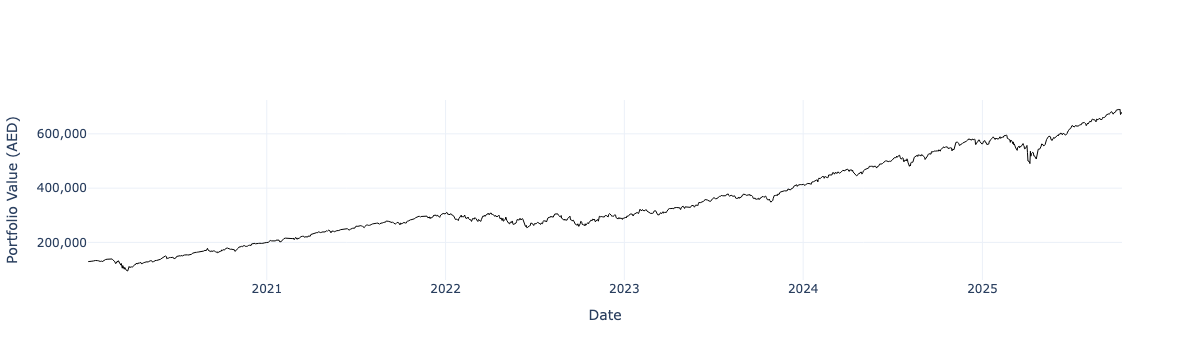

In [59]:
# --- snippet: portfolio_performance_chart
portfolio_performance_chart = go.Figure()

portfolio_performance_chart.add_trace(
    go.Scatter(
        x=investment_df.index,
        y=investment_df["Portfolio Value"],
        mode="lines",
        line=dict(color="black", width=1),
    )
)

portfolio_performance_chart.update_layout(
    xaxis_title="Date",
    yaxis_title=f"Portfolio Value ({currency})",
    template="plotly_white",
)

portfolio_performance_chart.update_yaxes(tickformat=",")

portfolio_performance_chart.show()
# --- endsnippet

In [60]:
# --- snippet: portfolio_performance_metrics
portfolio_value_end = investment_df["Portfolio Value"].to_numpy()[-1]
total_invested = investment_df["Investments"].sum()
total_dividends = investment_df["Dividend Income"].sum()
snp500_return = (
    portfolio_value_end + total_dividends - trading_fees.sum() - total_invested
) / total_invested

print(f"Total Investment ({currency}) = {total_invested:,.2f}")
print(f"Portfolio Value ({currency}) = {portfolio_value_end:,.2f}")
print(f"Dividend Income After Tax ({currency}) = {total_dividends:,.2f}")
print(f"Total Trading Cost = {investment_df['Trading Fees'].sum()}")

print(f"Holding Period Return = {snp500_return:.2%}")
# --- endsnippet

Total Investment (AED) = 371,500.00
Portfolio Value (AED) = 680,066.83
Dividend Income After Tax (AED) = 21,126.86
Total Trading Cost = 928.75
Holding Period Return = 88.50%
